In [1]:
# Data manipulation and analysis
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Preprocessing and feature engineering
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report

# Model saving
import joblib
import pickle

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

# Suppress warnings (optional)
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df=pd.read_csv("/content/drive/MyDrive/14 Days of ML/Heart Disease Detector Day_7 /heart_disease_uci.csv")
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [3]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (920, 16)


In [4]:
df.head(3)

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [6]:
df.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [7]:
# Making a copy to preserve original
df_clean = df.copy()

#  Fix target column - use 'num' as target, drop 'target'
df_clean['target'] = df_clean['num']
df_clean = df_clean.drop(['num', 'target_old'], errors='ignore')

#  Replace impossible values (0) with NaN
df_clean['trestbps'] = df_clean['trestbps'].replace(0, np.nan)
df_clean['chol'] = df_clean['chol'].replace(0, np.nan)

#  Show current missing values
print("Missing values before handling:")
print(df_clean.isnull().sum())

Missing values before handling:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     60
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
target        0
dtype: int64


In [8]:
df['ca'].value_counts()

,count
ca,
0.0,181
1.0,67
2.0,41
3.0,20


In [9]:
# Check missing percentages
missing_percentage = (df_clean.isnull().sum() / len(df_clean)) * 100
print("Missing percentage per column:")
print(missing_percentage[missing_percentage > 0].sort_values(ascending=False))

Missing percentage per column:
ca          66.413043
thal        52.826087
slope       33.586957
chol        21.956522
fbs          9.782609
oldpeak      6.739130
trestbps     6.521739
thalch       5.978261
exang        5.978261
restecg      0.217391
dtype: float64


In [10]:
# Check distribution of 'num' (target)
print(df_clean['num'].value_counts())
print("\nUnique values in thal:")
print(df_clean['thal'].unique())
print("\nUnique values in slope:")
print(df_clean['slope'].unique())

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Unique values in thal:
['fixed defect' 'normal' 'reversable defect' nan]

Unique values in slope:
['downsloping' 'flat' 'upsloping' nan]


In [11]:
# Droping columns with too many missing values
df_clean = df_clean.drop(['ca', 'thal', 'slope'], axis=1)

print(f"Shape after dropping columns: {df_clean.shape}")
print("\nRemaining missing values:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Shape after dropping columns: (920, 14)

Remaining missing values:
trestbps     60
chol        202
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
dtype: int64


In [12]:
#  Categorical columns  Mode imputation
for col in ['fbs', 'exang']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

#  Restecg - Mode imputation (categorical)
df_clean['restecg'] = df_clean['restecg'].fillna(df_clean['restecg'].mode()[0])

#  Continuous columns - Median imputation
for col in ['trestbps', 'chol', 'thalch', 'oldpeak']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# Verify no missing values remain
print("Remaining missing values:")
print(df_clean.isnull().sum().sum())
print("\nData types:")
print(df_clean.dtypes)

Remaining missing values:
0

Data types:
id            int64
age           int64
sex          object
dataset      object
cp           object
trestbps    float64
chol        float64
fbs            bool
restecg      object
thalch      float64
exang          bool
oldpeak     float64
num           int64
target        int64
dtype: object


In [13]:
# Droping 'id' column here (not useful for prediction)
df_clean = df_clean.drop('id', axis=1)

# Converting boolean to int (True=1, False=0)
df_clean['fbs'] = df_clean['fbs'].astype(int)
df_clean['exang'] = df_clean['exang'].astype(int)

# Encoding categorical variables using Label Encoding
from sklearn.preprocessing import LabelEncoder

categorical_cols = ['sex', 'dataset', 'cp', 'restecg']

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    le_dict[col] = le  # Save for future use

# Verify all columns are numeric
print("All columns numeric?")
print(df_clean.dtypes)
print("\nFirst 3 rows after encoding:")
print(df_clean.head(3))

All columns numeric?
age           int64
sex           int64
dataset       int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
num           int64
target        int64
dtype: object

First 3 rows after encoding:
   age  sex  dataset  cp  trestbps   chol  fbs  restecg  thalch  exang  \
0   63    1        0   3     145.0  233.0    1        0   150.0      0   
1   67    1        0   0     160.0  286.0    0        0   108.0      1   
2   67    1        0   0     120.0  229.0    0        0   129.0      1   

   oldpeak  num  target  
0      2.3    0       0  
1      1.5    2       2  
2      2.6    1       1  


In [14]:
#  'num' as target (0 = no disease, 1-4 = disease)
y = df_clean['num']
X = df_clean.drop(['num', 'target'], axis=1)  # Droping both target columns

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print("\nTarget distribution:")
print(y.value_counts().sort_index())
print(f"\nDisease present (num > 0): {(y > 0).sum()}")
print(f"No disease (num = 0): {(y == 0).sum()}")

X shape: (920, 11)
y shape: (920,)

Target distribution:
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Disease present (num > 0): 509
No disease (num = 0): 411


In [15]:
# Train Test Split

from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())
print("\nTest target distribution:")
print(y_test.value_counts().sort_index())

Training set size: (736, 11)
Test set size: (184, 11)

Training target distribution:
num
0    329
1    212
2     87
3     86
4     22
Name: count, dtype: int64

Test target distribution:
num
0    82
1    53
2    22
3    21
4     6
Name: count, dtype: int64


In [16]:
from sklearn.preprocessing import StandardScaler

# Initialize scaler
scaler = StandardScaler()

# Fit on training data, transform both train and test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier viewing
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Training data summary after scaling:")
print(X_train_scaled.describe().round(2))

Training data summary after scaling:
          age     sex  dataset      cp  trestbps    chol     fbs  restecg  \
count  736.00  736.00   736.00  736.00    736.00  736.00  736.00   736.00   
mean    -0.00    0.00     0.00    0.00     -0.00   -0.00    0.00     0.00   
std      1.00    1.00     1.00    1.00      1.00    1.00    1.00     1.00   
min     -2.69   -1.88    -1.07   -0.83     -2.88   -3.11   -0.41    -1.58   
25%     -0.67    0.53    -1.07   -0.83     -0.66   -0.50   -0.41     0.02   
50%      0.07    0.53    -0.19   -0.83     -0.10   -0.09   -0.41     0.02   
75%      0.71    0.53     0.69    1.25      0.45    0.41   -0.41     0.02   
max      2.51    0.53     1.57    2.29      3.78    7.01    2.45     1.61   

       thalch   exang  oldpeak  
count  736.00  736.00   736.00  
mean     0.00    0.00     0.00  
std      1.00    1.00     1.00  
min     -3.09   -0.75    -3.26  
25%     -0.71   -0.75    -0.80  
50%      0.08   -0.75    -0.33  
75%      0.69    1.34     0.62  
max  

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='mlogloss')
}

# Train and evaluate each model
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_score = model.score(X_train_scaled, y_train)
    test_score = model.score(X_test_scaled, y_test)
    results[name] = {'train': train_score, 'test': test_score}
    print(f"{name}:")
    print(f"  Train Accuracy: {train_score:.4f}")
    print(f"  Test Accuracy:  {test_score:.4f}")
    print("-" * 30)

Logistic Regression:
  Train Accuracy: 0.5938
  Test Accuracy:  0.5598
------------------------------
Random Forest:
  Train Accuracy: 1.0000
  Test Accuracy:  0.6141
------------------------------
XGBoost:
  Train Accuracy: 1.0000
  Test Accuracy:  0.6304
------------------------------


In [18]:
from sklearn.model_selection import cross_val_score

# Cross-validation scores (5-fold)
cv_results = {}
for name, model in models.items():
    # Use scaled training data for CV
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_results[name] = cv_scores
    print(f"{name}:")
    print(f"  CV Scores: {cv_scores}")
    print(f"  Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")
    print("-" * 35)

Logistic Regression:
  CV Scores: [0.57432432 0.54421769 0.56462585 0.57142857 0.57142857]
  Mean CV Accuracy: 0.5652 (+/- 0.0219)
-----------------------------------
Random Forest:
  CV Scores: [0.55405405 0.60544218 0.65306122 0.61904762 0.54421769]
  Mean CV Accuracy: 0.5952 (+/- 0.0816)
-----------------------------------
XGBoost:
  CV Scores: [0.5        0.57823129 0.58503401 0.57142857 0.53061224]
  Mean CV Accuracy: 0.5531 (+/- 0.0652)
-----------------------------------


In [19]:
# Alternative: Test set score vs CV mean
print("\nComparison:")
for name in models.keys():
    cv_mean = cv_results[name].mean()
    test_acc = results[name]['test']
    print(f"{name}:")
    print(f"  CV Mean: {cv_mean:.4f}")
    print(f"  Test:    {test_acc:.4f}")
    print(f"  Difference: {test_acc - cv_mean:.4f}")
    print("-" * 25)


Comparison:
Logistic Regression:
  CV Mean: 0.5652
  Test:    0.5598
  Difference: -0.0054
-------------------------
Random Forest:
  CV Mean: 0.5952
  Test:    0.6141
  Difference: 0.0190
-------------------------
XGBoost:
  CV Mean: 0.5531
  Test:    0.6304
  Difference: 0.0774
-------------------------


In [21]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Initialize Random Forest
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

# Grid search (reduced to save time)
grid_search = GridSearchCV(
    rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1
)

print("Starting Grid Search...")
grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Test Score: {grid_search.score(X_test_scaled, y_test):.4f}")

Starting Grid Search...
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
Best CV Score: 0.5979
Test Score: 0.6359


In [22]:
# Get the best model
best_rf = grid_search.best_estimator_

# Predictions
y_pred = best_rf.predict(X_test_scaled)
y_pred_proba = best_rf.predict_proba(X_test_scaled)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("===== Best Random Forest Model Evaluation =====")
print(f"Best Parameters: {grid_search.best_params_}")
print("-" * 40)

# Overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# For multi-class, use macro/weighted averages
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Precision (weighted): {precision:.4f}")
print(f"Recall (weighted): {recall:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

# ROC-AUC (one-vs-rest)
try:
    roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
    print(f"ROC-AUC (OVR): {roc_auc:.4f}")
except:
    print("ROC-AUC: Could not compute (check class labels)")

print("-" * 40)
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

===== Best Random Forest Model Evaluation =====
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}
----------------------------------------
Accuracy: 0.6359
Precision (weighted): 0.5974
Recall (weighted): 0.6359
F1-Score (weighted): 0.6150
ROC-AUC (OVR): 0.8427
----------------------------------------

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85        82
           1       0.59      0.62      0.61        53
           2       0.25      0.18      0.21        22
           3       0.32      0.33      0.33        21
           4       0.00      0.00      0.00         6

    accuracy                           0.64       184
   macro avg       0.39      0.41      0.40       184
weighted avg       0.60      0.64      0.62       184



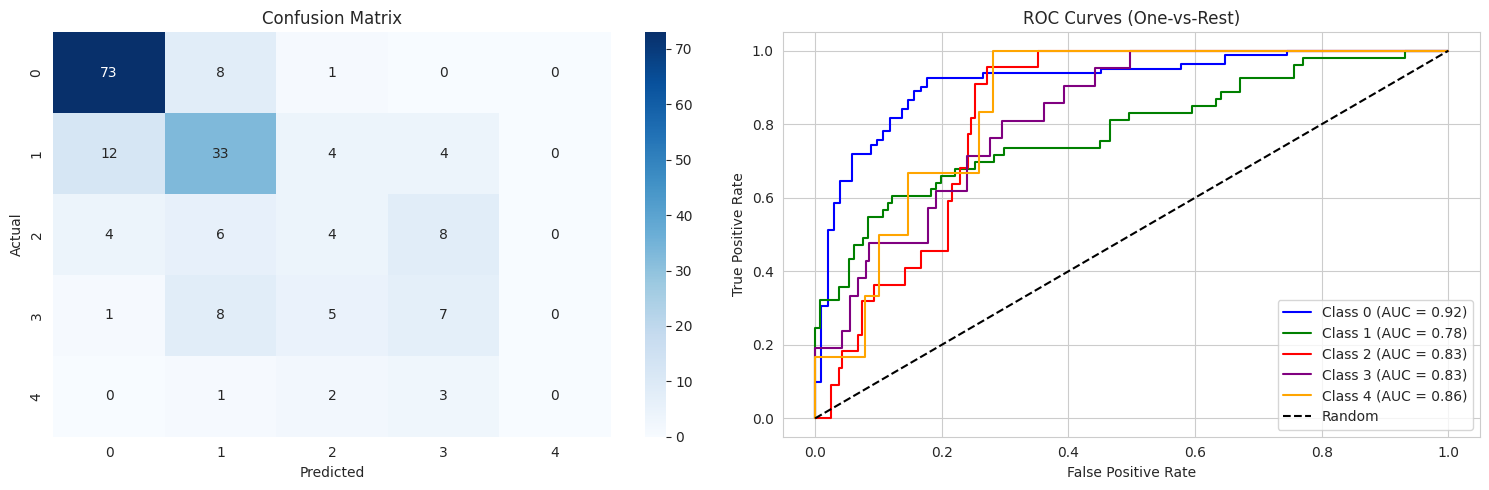

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

# Figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. ROC Curve (one-vs-rest)
n_classes = len(np.unique(y_test))
colors = ['blue', 'green', 'red', 'purple', 'orange']

for i in range(n_classes):
    # Binary relevance for class i
    y_test_binary = (y_test == i).astype(int)
    y_pred_binary = y_pred_proba[:, i]

    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_binary)
    roc_auc = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color=colors[i % len(colors)],
                 label=f'Class {i} (AUC = {roc_auc:.2f})')

axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (One-vs-Rest)')
axes[1].legend(loc='lower right')
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [24]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

# Combine rare classes (2,3,4) into one "high risk" class
y_train_binary = y_train.copy()
y_test_binary = y_test.copy()

# Map: 0 = No disease, 1 = Mild (class 1), 2 = Severe (classes 2,3,4)
y_train_binary = y_train.replace({2: 2, 3: 2, 4: 2})
y_test_binary = y_test.replace({2: 2, 3: 2, 4: 2})

print("Original distribution vs Binary distribution:")
print("Original:", y_train.value_counts().sort_index().tolist())
print("Binary:  ", y_train_binary.value_counts().sort_index().tolist())

Original distribution vs Binary distribution:
Original: [329, 212, 87, 86, 22]
Binary:   [329, 212, 195]


In [25]:
# Create binary target
y_train_binary = y_train.replace({2: 2, 3: 2, 4: 2})
y_test_binary = y_test.replace({2: 2, 3: 2, 4: 2})

# Retrain Random Forest with best parameters
best_rf_binary = RandomForestClassifier(
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

best_rf_binary.fit(X_train_scaled, y_train_binary)

# Predictions
y_pred_binary = best_rf_binary.predict(X_test_scaled)
y_pred_proba_binary = best_rf_binary.predict_proba(X_test_scaled)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("===== Binary Classification (3 Classes) =====")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_binary):.4f}")
print(f"Precision (weighted): {precision_score(y_test_binary, y_pred_binary, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test_binary, y_pred_binary, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test_binary, y_pred_binary, average='weighted'):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_binary, y_pred_binary))

===== Binary Classification (3 Classes) =====
Accuracy: 0.7446
Precision (weighted): 0.7431
Recall (weighted): 0.7446
F1-Score (weighted): 0.7396

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.85      0.85        82
           1       0.64      0.51      0.57        53
           2       0.67      0.82      0.73        49

    accuracy                           0.74       184
   macro avg       0.72      0.73      0.72       184
weighted avg       0.74      0.74      0.74       184



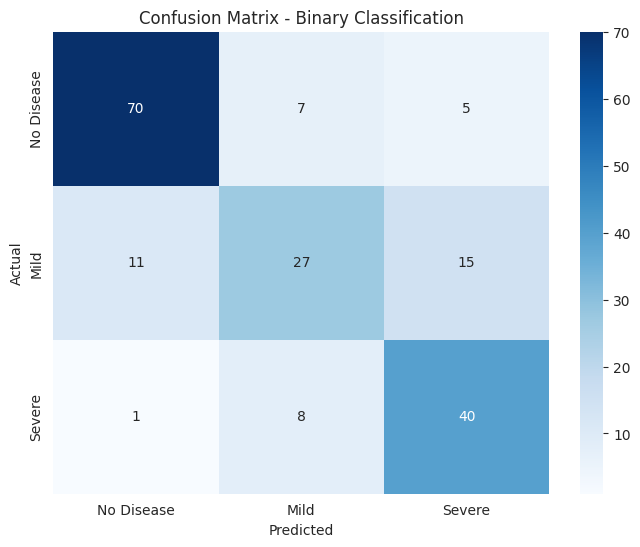

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Confusion Matrix
cm_binary = confusion_matrix(y_test_binary, y_pred_binary)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_binary, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease', 'Mild', 'Severe'],
            yticklabels=['No Disease', 'Mild', 'Severe'])
plt.title('Confusion Matrix - Binary Classification')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [30]:
# Create new features from existing ones (properly handling NaN)
X_train_enhanced = X_train_scaled.copy()
X_test_enhanced = X_test_scaled.copy()

# 1. Blood Pressure Ratio (BP to max heart rate)
X_train_enhanced['bp_ratio'] = X_train_enhanced['trestbps'] / (X_train_enhanced['thalch'] + 1e-5)
X_test_enhanced['bp_ratio'] = X_test_enhanced['trestbps'] / (X_test_enhanced['thalch'] + 1e-5)

# 2. Age-BP interaction (older people with high BP = higher risk)
X_train_enhanced['age_bp'] = X_train_enhanced['age'] * X_train_enhanced['trestbps']
X_test_enhanced['age_bp'] = X_test_enhanced['age'] * X_test_enhanced['trestbps']

# 3. Cholesterol to BP ratio
X_train_enhanced['chol_bp_ratio'] = X_train_enhanced['chol'] / (X_train_enhanced['trestbps'] + 1e-5)
X_test_enhanced['chol_bp_ratio'] = X_test_enhanced['chol'] / (X_test_enhanced['trestbps'] + 1e-5)

# 4. Age group (using pd.cut, but without creating NaN)
# Instead of pd.cut, use simple binning that doesn't produce NaN
X_train_enhanced['age_group'] = 0  # default
X_train_enhanced.loc[X_train_enhanced['age'] > 55, 'age_group'] = 2
X_train_enhanced.loc[(X_train_enhanced['age'] > 40) & (X_train_enhanced['age'] <= 55), 'age_group'] = 1

X_test_enhanced['age_group'] = 0
X_test_enhanced.loc[X_test_enhanced['age'] > 55, 'age_group'] = 2
X_test_enhanced.loc[(X_test_enhanced['age'] > 40) & (X_test_enhanced['age'] <= 55), 'age_group'] = 1

print(f"Original features: {X_train_scaled.shape[1]}")
print(f"Enhanced features: {X_train_enhanced.shape[1]}")
print("\nNew features added:")
print("- bp_ratio (BP to max heart rate)")
print("- age_bp (age * BP interaction)")
print("- chol_bp_ratio (cholesterol to BP ratio)")
print("- age_group (categorical age bins)")

# Verify no NaN
print(f"\nNaN in X_train_enhanced: {X_train_enhanced.isnull().sum().sum()}")
print(f"NaN in X_test_enhanced: {X_test_enhanced.isnull().sum().sum()}")

Original features: 11
Enhanced features: 15

New features added:
- bp_ratio (BP to max heart rate)
- age_bp (age * BP interaction)
- chol_bp_ratio (cholesterol to BP ratio)
- age_group (categorical age bins)

NaN in X_train_enhanced: 0
NaN in X_test_enhanced: 0


In [31]:
# Retrain Random Forest with enhanced features
rf_enhanced = RandomForestClassifier(
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_enhanced.fit(X_train_enhanced, y_train_binary)
y_pred_enhanced = rf_enhanced.predict(X_test_enhanced)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("===== Enhanced Random Forest Performance =====")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_enhanced):.4f}")
print(f"Precision (weighted): {precision_score(y_test_binary, y_pred_enhanced, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test_binary, y_pred_enhanced, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test_binary, y_pred_enhanced, average='weighted'):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_binary, y_pred_enhanced))

===== Enhanced Random Forest Performance =====
Accuracy: 0.7174
Precision (weighted): 0.7166
Recall (weighted): 0.7174
F1-Score (weighted): 0.7110

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83        82
           1       0.64      0.47      0.54        53
           2       0.62      0.78      0.69        49

    accuracy                           0.72       184
   macro avg       0.70      0.70      0.69       184
weighted avg       0.72      0.72      0.71       184



In [32]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_enhanced, y_train_binary)

print("Before SMOTE:", y_train_binary.value_counts().sort_index().tolist())
print("After SMOTE: ", pd.Series(y_train_smote).value_counts().sort_index().tolist())

# Train with SMOTE
rf_smote = RandomForestClassifier(
    max_depth=None,
    max_features='sqrt',
    min_samples_leaf=2,
    min_samples_split=5,
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test_enhanced)

print("\n===== SMOTE + Enhanced Features =====")
print(f"Accuracy: {accuracy_score(y_test_binary, y_pred_smote):.4f}")
print(f"Precision (weighted): {precision_score(y_test_binary, y_pred_smote, average='weighted'):.4f}")
print(f"Recall (weighted): {recall_score(y_test_binary, y_pred_smote, average='weighted'):.4f}")
print(f"F1-Score (weighted): {f1_score(y_test_binary, y_pred_smote, average='weighted'):.4f}")

print("\nDetailed Classification Report:")
print(classification_report(y_test_binary, y_pred_smote))

Before SMOTE: [329, 212, 195]
After SMOTE:  [329, 329, 329]

===== SMOTE + Enhanced Features =====
Accuracy: 0.6793
Precision (weighted): 0.6886
Recall (weighted): 0.6793
F1-Score (weighted): 0.6798

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.80      0.84        82
           1       0.53      0.45      0.49        53
           2       0.56      0.71      0.62        49

    accuracy                           0.68       184
   macro avg       0.65      0.66      0.65       184
weighted avg       0.69      0.68      0.68       184



In [37]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Original RF', 'Enhanced RF', 'SMOTE + Enhanced'],
    'Accuracy': [
        accuracy_score(y_test_binary, y_pred_binary),
        accuracy_score(y_test_binary, y_pred_enhanced),
        accuracy_score(y_test_binary, y_pred_smote)
    ],
    'F1 (Weighted)': [
        f1_score(y_test_binary, y_pred_binary, average='weighted'),
        f1_score(y_test_binary, y_pred_enhanced, average='weighted'),
        f1_score(y_test_binary, y_pred_smote, average='weighted')
    ]
})

print("===== Performance Comparison =====")
print(comparison.round(4))

# Best model
best_model = rf_smote if comparison.iloc[2, 1] > comparison.iloc[1, 1] else rf_enhanced
best_score = max(comparison.iloc[1:, 1].max(), comparison.iloc[1:, 2].max())
print(f"\nBest Model: {comparison.iloc[comparison['F1 (Weighted)'].idxmax(), 0]}")
print(f"   F1-Score: {comparison['F1 (Weighted)'].max():.4f}")

===== Performance Comparison =====
              Model  Accuracy  F1 (Weighted)
0       Original RF    0.7446         0.7396
1       Enhanced RF    0.7174         0.7110
2  SMOTE + Enhanced    0.6793         0.6798

Best Model: Original RF
   F1-Score: 0.7396


In [34]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': ['Original RF', 'Enhanced RF', 'SMOTE + Enhanced'],
    'Accuracy': [
        accuracy_score(y_test_binary, y_pred_binary),
        accuracy_score(y_test_binary, y_pred_enhanced),
        accuracy_score(y_test_binary, y_pred_smote)
    ],
    'F1 (Weighted)': [
        f1_score(y_test_binary, y_pred_binary, average='weighted'),
        f1_score(y_test_binary, y_pred_enhanced, average='weighted'),
        f1_score(y_test_binary, y_pred_smote, average='weighted')
    ]
})

print("===== Performance Comparison =====")
print(comparison.round(4))

# Best model
best_idx = comparison['F1 (Weighted)'].idxmax()
print(f"\nBest Model: {comparison.iloc[best_idx, 0]}")
print(f"   Accuracy: {comparison.iloc[best_idx, 1]:.4f}")
print(f"   F1-Score: {comparison.iloc[best_idx, 2]:.4f}")

===== Performance Comparison =====
              Model  Accuracy  F1 (Weighted)
0       Original RF    0.7446         0.7396
1       Enhanced RF    0.7174         0.7110
2  SMOTE + Enhanced    0.6793         0.6798

Best Model: Original RF
   Accuracy: 0.7446
   F1-Score: 0.7396


In [38]:
# Define final_model as the best model
final_model = best_rf_binary
print("final_model defined successfully!")

final_model defined successfully!


In [40]:
# Define feature_names from your training data
feature_names = X_train.columns.tolist()
print(" feature_names defined!")
print(f"Features: {feature_names}")

 feature_names defined!
Features: ['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak']


In [41]:
import joblib
import os

# Your specific folder path
folder_path = '/content/drive/MyDrive/14 Days of ML/Heart Disease Detector Day_7/'

# Create folder if it doesn't exist
os.makedirs(folder_path, exist_ok=True)
print(f" Folder verified: {folder_path}")

# Save model, scaler, and feature names
joblib.dump(final_model, os.path.join(folder_path, 'heart_disease_model.pkl'))
joblib.dump(scaler, os.path.join(folder_path, 'scaler.pkl'))

# Save feature names
with open(os.path.join(folder_path, 'feature_names.txt'), 'w') as f:
    for feature in feature_names:
        f.write(f"{feature}\n")

print("\nAll files saved to Google Drive!")
print(f"\n Location: {folder_path}")
print("\nFiles saved:")
print("- heart_disease_model.pkl")
print("- scaler.pkl")
print("- feature_names.txt")

 Folder verified: /content/drive/MyDrive/14 Days of ML/Heart Disease Detector Day_7/

All files saved to Google Drive!

 Location: /content/drive/MyDrive/14 Days of ML/Heart Disease Detector Day_7/

Files saved:
- heart_disease_model.pkl
- scaler.pkl
- feature_names.txt


In [42]:
import os

folder_path = '/content/drive/MyDrive/14 Days of ML/Heart Disease Detector Day_7/'

# List files in folder
files = os.listdir(folder_path)
print(f"Files in {folder_path}:")
for file in files:
    size = os.path.getsize(os.path.join(folder_path, file))
    print(f"  - {file} ({size/1024:.1f} KB)")

# Test loading
print("\n Verifying model can be loaded...")
loaded_model = joblib.load(os.path.join(folder_path, 'heart_disease_model.pkl'))
print(f"Model loaded successfully! Expected features: {len(loaded_model.feature_names_in_)}")

Files in /content/drive/MyDrive/14 Days of ML/Heart Disease Detector Day_7/:
  - heart_disease_model.pkl (2040.0 KB)
  - scaler.pkl (1.2 KB)
  - feature_names.txt (0.1 KB)

 Verifying model can be loaded...
Model loaded successfully! Expected features: 11
